In [ ]:
import pandas as pd

# 1. Cargar el archivo original (Kaggle)
# Usamos encoding='latin1' por si el original tiene caracteres brasileños
df = pd.read_csv('KaggleV2-May-2016.csv', encoding='latin1')

# 2. Diccionario de traducción para los encabezados (si deseas ponerlos en español)
# Esto evita tener que lidiar con nombres en portugués
traduccion_columnas = {
    'Hipertension': 'Hipertension',
    'Handcap': 'Discapacidad',
    'Neighbourhood': 'Barrio'
}
df.rename(columns=traduccion_columnas, inplace=True)

# 3. Función para limpiar caracteres raros en los BARRIOS (Neighbourhood)
def limpiar_texto(texto):
    if isinstance(texto, str):
        import unicodedata
        # Elimina acentos y convierte a formato ASCII simple
        texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('ascii')
        return texto
    return texto

# Aplicamos la limpieza a la columna de barrios/localidades
df['Barrio'] = df['Barrio'].apply(limpiar_texto)

# 4. Verificamos el volumen original
print(f"Dataset cargado exitosamente.")
print(f"Total de registros originales: {df.shape[0]}")
print(df.columns.tolist())

Dataset cargado exitosamente.
Total de registros originales: 110527
['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Barrio', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Discapacidad', 'SMS_received', 'No-show']



--- DISTRIBUCIÓN DE LA VARIABLE 'No-show' ---
         Cantidad  Porcentaje (%)
No-show                          
No          88208           79.81
Yes         22319           20.19


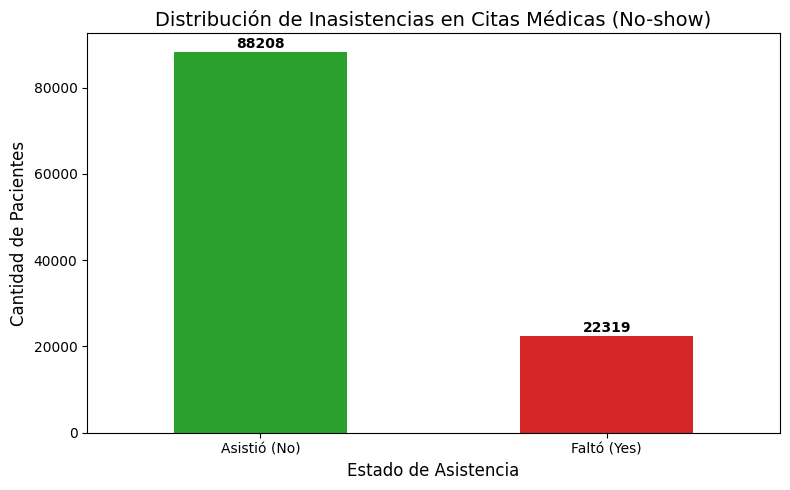

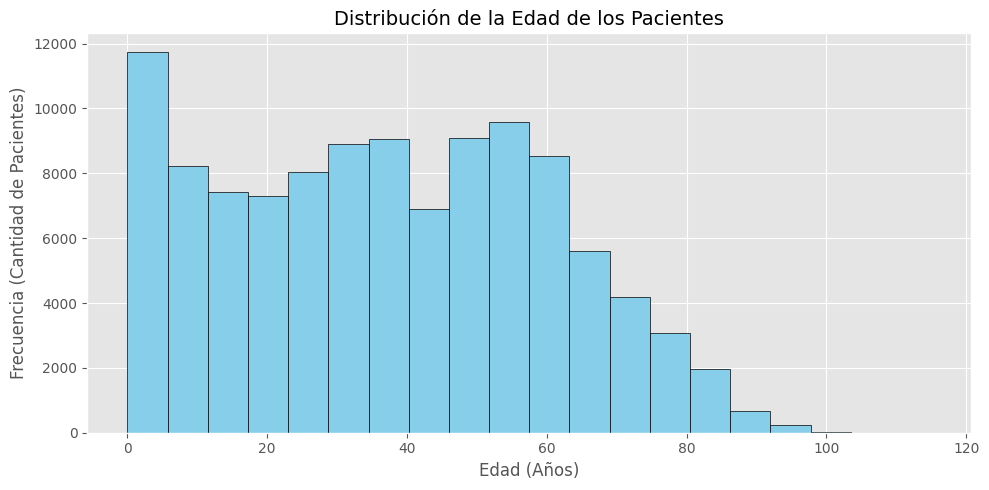

<Figure size 800x500 with 0 Axes>

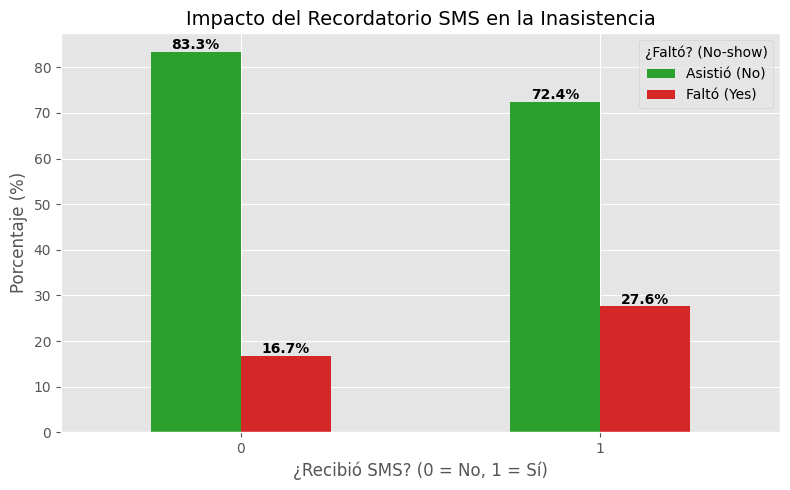

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata

# 1. Cargar el archivo ORIGINAL de Kaggle
# Ya no necesitamos sep=';' ni on_bad_lines porque el archivo original es perfecto
df = pd.read_csv('KaggleV2-May-2016.csv', encoding='latin1')

# 2. Re-aplicamos la traducción y limpieza (para asegurar que las variables se llamen igual en todo el proceso)
traduccion_columnas = {
    'Hipertension': 'Hipertension',
    'Handcap': 'Discapacidad',
    'Neighbourhood': 'Barrio'
}
df.rename(columns=traduccion_columnas, inplace=True)

def limpiar_texto(texto):
    if isinstance(texto, str):
        texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('ascii')
        return texto
    return texto

df['Barrio'] = df['Barrio'].apply(limpiar_texto)

# ==========================================
# EVIDENCIA 1: ANÁLISIS DE LA VARIABLE OBJETIVO (No-show)
# ==========================================
print("\n--- DISTRIBUCIÓN DE LA VARIABLE 'No-show' ---")
conteo = df['No-show'].value_counts()
porcentaje = df['No-show'].value_counts(normalize=True) * 100

distribucion_df = pd.DataFrame({'Cantidad': conteo, 'Porcentaje (%)': porcentaje})
print(distribucion_df.round(2))

# GRÁFICA 1: BARRAS TARGET
plt.figure(figsize=(8, 5))
colores = ['#2ca02c', '#d62728']
ax = conteo.plot(kind='bar', color=colores)
plt.title('Distribución de Inasistencias en Citas Médicas (No-show)', fontsize=14)
plt.xlabel('Estado de Asistencia', fontsize=12)
plt.ylabel('Cantidad de Pacientes', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Asistió (No)', 'Faltó (Yes)'], rotation=0)

for i, v in enumerate(conteo):
    ax.text(i, v + 1000, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show() # TOMA CAPTURA DE ESTO (Gráfica Verde y Roja)


print("\n" + "="*50 + "\n")


# ==========================================
# EVIDENCIA 2: ANÁLISIS EXPLORATORIO ADICIONAL (EDA)
# ==========================================
plt.style.use('ggplot')

# GRÁFICA 2: HISTOGRAMA DE EDADES
plt.figure(figsize=(10, 5))
# Forzamos la edad a numérico (por si acaso el original tiene algún error) y filtramos edades negativas
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
edades_validas = df[df['Age'] >= 0]['Age'].dropna()

plt.hist(edades_validas, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución de la Edad de los Pacientes', fontsize=14)
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Pacientes)', fontsize=12)
plt.tight_layout()
plt.show() # TOMA CAPTURA DE ESTO (Gráfica Celeste)

print("\n" + "="*50 + "\n")

# GRÁFICA 3: IMPACTO DEL SMS EN LA INASISTENCIA
plt.figure(figsize=(8, 5))
sms_impacto = pd.crosstab(df['SMS_received'], df['No-show'], normalize='index') * 100

ax = sms_impacto.plot(kind='bar', stacked=False, color=['#2ca02c', '#d62728'], figsize=(8,5))
plt.title('Impacto del Recordatorio SMS en la Inasistencia', fontsize=14)
plt.xlabel('¿Recibió SMS? (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.legend(title='¿Faltó? (No-show)', labels=['Asistió (No)', 'Faltó (Yes)'])
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show() # TOMA CAPTURA DE ESTO (Gráfica de Barras SMS)

In [ ]:
# ==========================================
# DIAGNÓSTICO INICIAL DE INTEGRIDAD (EVIDENCIA)
# ==========================================

# 1. Contar valores nulos por columna
nulos_por_columna = df.isnull().sum()
nulos_totales = nulos_por_columna.sum()

# 2. Contar registros duplicados
duplicados_totales = df.duplicated().sum()

print("--- DIAGNÓSTICO DE INTEGRIDAD INICIAL ---")
print("Valores nulos detectados por característica:")
print(nulos_por_columna)
print("-" * 30)
print(f"Total de valores nulos en el Data-Set: {nulos_totales}")
print(f"Total de registros duplicados detectados: {duplicados_totales}")

--- DIAGNÓSTICO DE INTEGRIDAD INICIAL ---
Valores nulos detectados por característica:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Barrio            0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Discapacidad      0
SMS_received      0
No-show           0
dtype: int64
------------------------------
Total de valores nulos en el Data-Set: 0
Total de registros duplicados detectados: 0


In [ ]:
import pandas as pd
import unicodedata

# ==========================================
# 0. CARGAR Y PREPARAR DATOS DESDE CERO
# ==========================================
df = pd.read_csv('KaggleV2-May-2016.csv', encoding='latin1')
df.rename(columns={'Hipertension': 'Hipertension', 'Handcap': 'Discapacidad', 'Neighbourhood': 'Barrio'}, inplace=True)

def limpiar_texto(texto):
    if isinstance(texto, str):
        return unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('ascii')
    return texto
df['Barrio'] = df['Barrio'].apply(limpiar_texto)

# ==========================================
# 3.2.1 LIMPIEZA Y FILTRADO ESTRUCTURAL
# ==========================================
volumen_original = df.shape[0]

# Eliminar IDs
df = df.drop(['PatientId', 'AppointmentID'], axis=1, errors='ignore')

# Limpiar edades (programación defensiva)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df = df[df['Age'] >= 0]

# Limpiar fechas
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'], errors='coerce').dt.normalize()
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'], errors='coerce').dt.normalize()
df = df.dropna(subset=['ScheduledDay', 'AppointmentDay', 'Age'])

# Filtrar fechas lógicas
df = df[df['AppointmentDay'] >= df['ScheduledDay']]

volumen_limpio = df.shape[0]
filas_eliminadas = volumen_original - volumen_limpio

print("--- RESULTADOS DE LA LIMPIEZA ESTRUCTURAL (3.2.1) ---")
print(f"Columnas eliminadas: 'PatientId', 'AppointmentID'")
print(f"Filas eliminadas por datos ilógicos: {filas_eliminadas}")
print(f"Nuevo volumen del Dataset: {volumen_limpio} registros")
print(f"Total de características restantes: {df.shape[1]}\n")

--- RESULTADOS DE LA LIMPIEZA ESTRUCTURAL (3.2.1) ---
Columnas eliminadas: 'PatientId', 'AppointmentID'
Filas eliminadas por datos ilógicos: 6
Nuevo volumen del Dataset: 110521 registros
Total de características restantes: 12



In [ ]:
# ==========================================
# 3.2.2 INGENIERÍA DE CARACTERÍSTICAS TEMPORALES
# ==========================================

# 1. Calcular el Tiempo de Espera (Lead Time)
df['LeadTime'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

# 2. Extraer el día de la semana de la cita (0 = Lunes... 6 = Domingo)
df['DayOfWeek'] = df['AppointmentDay'].dt.dayofweek

# 3. Eliminar las columnas de fecha originales (usamos errors='ignore' para evitar KeyError si se ejecuta 2 veces)
df = df.drop(['ScheduledDay', 'AppointmentDay'], axis=1, errors='ignore')

# Resultados
print("--- RESULTADOS DE INGENIERÍA DE CARACTERÍSTICAS (3.2.2) ---")
print(f"Nuevas variables: 'LeadTime' y 'DayOfWeek'")
print(f"Columnas de fecha eliminadas: 'ScheduledDay', 'AppointmentDay'")
print(f"Total de características actuales: {df.shape[1]}")
print("\nVista previa (Primeros 5 pacientes limpios):")
print(df[['Age', 'LeadTime', 'DayOfWeek', 'No-show']].head())

--- RESULTADOS DE INGENIERÍA DE CARACTERÍSTICAS (3.2.2) ---
Nuevas variables: 'LeadTime' y 'DayOfWeek'
Columnas de fecha eliminadas: 'ScheduledDay', 'AppointmentDay'
Total de características actuales: 12

Vista previa (Primeros 5 pacientes limpios):
   Age  LeadTime  DayOfWeek No-show
0   62         0          4      No
1   56         0          4      No
2   62         0          4      No
3    8         0          4      No
4   56         0          4      No


In [ ]:
from sklearn.preprocessing import LabelEncoder

# ==========================================
# 3.2.3 CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# ==========================================

# 1. Transformar variables binarias (usamos errors='ignore' para evitar fallos si se corre 2 veces)
# Convertimos M/F a 0/1 y No/Yes a 0/1
df['Gender'] = df['Gender'].map({'M': 0, 'F': 1})
df['No-show'] = df['No-show'].map({'No': 0, 'Yes': 1})

# 2. Transformar la columna de barrios brasileños ('Barrio') usando LabelEncoder
# Esto le asignará un número único a cada barrio (ej. Jardim da Penha = 1, Centro = 2)
le_barrios = LabelEncoder()
# Si te fijas, ahora usamos 'Barrio' porque en la Celda 1 la renombramos de 'Neighbourhood' a 'Barrio'
df['Barrio'] = le_barrios.fit_transform(df['Barrio'])

# 3. Mostrar los resultados en consola
print("--- RESULTADOS DE LA CODIFICACIÓN (3.2.3) ---")
print("Transformaciones aplicadas:")
print("- 'Gender': M -> 0, F -> 1")
print("- 'No-show' (Target): Asistió (No) -> 0, Faltó (Yes) -> 1")
print(f"- 'Barrio': Convertido a {df['Barrio'].nunique()} números únicos correspondientes a los barrios de Vitória.")
print("\nVista previa de los primeros 5 pacientes (Variables codificadas):")
print(df[['Gender', 'Barrio', 'No-show']].head())

--- RESULTADOS DE LA CODIFICACIÓN (3.2.3) ---
Transformaciones aplicadas:
- 'Gender': M -> 0, F -> 1
- 'No-show' (Target): Asistió (No) -> 0, Faltó (Yes) -> 1
- 'Barrio': Convertido a 81 números únicos correspondientes a los barrios de Vitória.

Vista previa de los primeros 5 pacientes (Variables codificadas):
   Gender  Barrio  No-show
0       1      39        0
1       0      39        0
2       1      46        0
3       1      54        0
4       1      39        0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# 3.2.4 NORMALIZACIÓN DE VARIABLES NUMÉRICAS
# ==========================================

# 1. Instanciar el escalador
scaler = MinMaxScaler()

# 2. Seleccionar las columnas con rangos numéricos grandes que necesitan compresión
columnas_numericas = ['Age', 'LeadTime']

# 3. Aplicar la transformación a esas columnas específicas
df[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])

# 4. Mostrar los resultados en consola
print("--- RESULTADOS DE LA NORMALIZACIÓN (3.2.4) ---")
print(f"Variables escaladas al rango [0, 1]: {columnas_numericas}")
print("\nVista previa de las variables numéricas (Primeros 5 pacientes):")
print(df[columnas_numericas].head())

--- RESULTADOS DE LA NORMALIZACIÓN (3.2.4) ---
Variables escaladas al rango [0, 1]: ['Age', 'LeadTime']

Vista previa de las variables numéricas (Primeros 5 pacientes):
        Age  LeadTime
0  0.539130       0.0
1  0.486957       0.0
2  0.539130       0.0
3  0.069565       0.0
4  0.486957       0.0


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# ==========================================
# 3.2.5 PREPARACIÓN PARA EL DESBALANCE DE CLASES
# ==========================================

# 1. Extraer la variable objetivo (Target)
y = df['No-show'].values

# 2. Calcular los pesos balanceados matemáticamente
pesos = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)

# 3. Formatear el resultado como un diccionario para el algoritmo
pesos_clases = {0: pesos[0], 1: pesos[1]}

# 4. Mostrar los resultados en consola
print("--- ESTRATEGIA DE BALANCEO DE CLASES (3.2.5) ---")
print("Distribución original detectada: ~80% (Clase 0) / ~20% (Clase 1)")
print(f"Pesos calculados por el algoritmo: {pesos_clases}")
print("\nInterpretación para el modelo de Machine Learning:")
print(f"- Por cada paciente que SÍ ASISTE (0), el modelo le dará una importancia de {pesos[0]:.4f}")
print(f"- Por cada paciente que FALTA (1), el modelo le dará una importancia de {pesos[1]:.4f}")

--- ESTRATEGIA DE BALANCEO DE CLASES (3.2.5) ---
Distribución original detectada: ~80% (Clase 0) / ~20% (Clase 1)
Pesos calculados por el algoritmo: {0: np.float64(0.6264865600235809), 1: np.float64(2.476494577395357)}

Interpretación para el modelo de Machine Learning:
- Por cada paciente que SÍ ASISTE (0), el modelo le dará una importancia de 0.6265
- Por cada paciente que FALTA (1), el modelo le dará una importancia de 2.4765


In [ ]:
from sklearn.model_selection import train_test_split

# ==========================================
# 3.3 PARTICIÓN DEL DATASET (TRAIN / TEST)
# ==========================================

# 1. Separar las características (X - las preguntas) de la variable objetivo (y - la respuesta)
X = df.drop('No-show', axis=1)
y = df['No-show']

# 2. Dividir los datos: 80% para Entrenar (Training) y 20% para Pruebas (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. Mostrar los resultados en consola
print("--- PARTICIÓN DEL DATA-SET (3.3) ---")
print(f"Total de registros originales (Limpios): {len(df)}")
print("-" * 40)
print(f"Data-Set de Entrenamiento (Training - 80%): {len(X_train)} pacientes")
print(f"Data-Set de Pruebas (Test - 20%): {len(X_test)} pacientes")
print("-" * 40)
print(f"Cantidad de variables predictoras en X: {X_train.shape[1]}")

--- PARTICIÓN DEL DATA-SET (3.3) ---
Total de registros originales (Limpios): 110521
----------------------------------------
Data-Set de Entrenamiento (Training - 80%): 88416 pacientes
Data-Set de Pruebas (Test - 20%): 22105 pacientes
----------------------------------------
Cantidad de variables predictoras en X: 11


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ==========================================================
# 4.2.1. CONFIGURACIÓN DE MODELOS CON PESOS DE CLASES
# ==========================================================

# Definición de los pesos calculados en el paso 3.2.5
# pesos_clases = {0: 0.62654865, 1: 2.47649458}
peso_positivo_xgboost = 2.47649458 / 0.62654865  # Ratio para scale_pos_weight

modelos = {
    "Regresión Logística": LogisticRegression(
        class_weight={0: 0.6265, 1: 2.4765},
        random_state=42,
        max_iter=1000
    ),
    "Random Forest": RandomForestClassifier(
        class_weight={0: 0.6265, 1: 2.4765},
        random_state=42,
        n_estimators=100,
        max_depth=10
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=peso_positivo_xgboost,
        random_state=42,
        n_estimators=100,
        max_depth=6,
        eval_metric='logloss'
    )
}

# ==========================================================
# 4.2.2. VALIDACIÓN CRUZADA ESTRATIFICADA (5-FOLD CV)
# ==========================================================
print("--- EJECUTANDO VALIDACIÓN CRUZADA ESTRATIFICADA (5 PLIEGUES) ---")
cv_estrategia = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metricas_cv = ['recall', 'precision', 'f1', 'roc_auc']

for nombre, modelo in modelos.items():
    resultados_cv = cross_validate(
        modelo, X_train, y_train,
        cv=cv_estrategia,
        scoring=metricas_cv,
        n_jobs=-1
    )
    print(f"\n[+] {nombre}:")
    print(f"    -> Mean Recall (Inasistencias): {np.mean(resultados_cv['test_recall']):.4f}")
    print(f"    -> Mean Precision:              {np.mean(resultados_cv['test_precision']):.4f}")
    print(f"    -> Mean F1-Score:               {np.mean(resultados_cv['test_f1']):.4f}")
    print(f"    -> Mean ROC-AUC:                {np.mean(resultados_cv['test_roc_auc']):.4f}")

# ==========================================================
# 4.2.3. ENTRENAMIENTO FINAL Y EVALUACIÓN CON SET DE PRUEBAS
# ==========================================================
print("\n--- EVALUACIÓN FINAL SOBRE EL DATA-SET DE PRUEBAS (TEST SET) ---")

# Para este reporte ejecutamos la evaluación con el modelo seleccionado por desempeño (ej. XGBoost)
modelo_seleccionado = modelos["XGBoost"]
modelo_seleccionado.fit(X_train, y_train)
predicciones = modelo_seleccionado.predict(X_test)
probabilidades = modelo_seleccionado.predict_proba(X_test)[:, 1]

print("\nMatriz de Confusión Final (XGBoost):")
print(confusion_matrix(y_test, predicciones))

print("\nReporte de Clasificación Final (XGBoost):")
print(classification_report(y_test, predicciones, target_names=['Asistió (0)', 'Faltó (1)']))

print(f"ROC-AUC Score Final en Test: {roc_auc_score(y_test, probabilidades):.4f}")

--- EJECUTANDO VALIDACIÓN CRUZADA ESTRATIFICADA (5 PLIEGUES) ---

[+] Regresión Logística:
    -> Mean Recall (Inasistencias): 0.5637
    -> Mean Precision:              0.3180
    -> Mean F1-Score:               0.4066
    -> Mean ROC-AUC:                0.6668

[+] Random Forest:
    -> Mean Recall (Inasistencias): 0.7976
    -> Mean Precision:              0.3100
    -> Mean F1-Score:               0.4465
    -> Mean ROC-AUC:                0.7332

[+] XGBoost:
    -> Mean Recall (Inasistencias): 0.7407
    -> Mean Precision:              0.3186
    -> Mean F1-Score:               0.4456
    -> Mean ROC-AUC:                0.7345

--- EVALUACIÓN FINAL SOBRE EL DATA-SET DE PRUEBAS (TEST SET) ---

Matriz de Confusión Final (XGBoost):
[[10322  7320]
 [ 1114  3349]]

Reporte de Clasificación Final (XGBoost):
              precision    recall  f1-score   support

 Asistió (0)       0.90      0.59      0.71     17642
   Faltó (1)       0.31      0.75      0.44      4463

    accuracy     

In [ ]:
from sklearn.metrics import recall_score, precision_score, f1_score
# ==========================================================
# 5.1 CÁLCULO DE MÉTRICAS FINALES Y RESUMEN (XGBoost)
# Usamos tus variables: 'predicciones' y 'probabilidades'
# ==========================================================
# Calculamos las métricas
recall_test = recall_score(y_test, predicciones)
auc_test = roc_auc_score(y_test, probabilidades)
precision_test = precision_score(y_test, predicciones)
f1_test = f1_score(y_test, predicciones)
# Imprimimos el resumen formal para tu documento
print("=" * 65)
print("RESULTADOS - EVALUACIÓN FINAL SOBRE TEST SET (XGBoost)")
print("=" * 65)
print(f" Recall    : {recall_test:.4f}")
print(f" ROC-AUC   : {auc_test:.4f}")
print(f" Precision : {precision_test:.4f}")
print(f" F1-Score  : {f1_test:.4f}")
print("=" * 65)
# ==========================================================
# TABLA 3: RESUMEN DE PRUEBA FINAL
# (Versión adaptada a tus variables para evitar errores)
# ==========================================================
print("\n" + "=" * 65)
print(f"{'Modelo Seleccionado' :<25} {'Recall Test':>15} {'AUC Test':>15}")
print("-" * 65)
print(f"{'XGBoost (Modelo Final)' :<25} {recall_test:>15.4f} {auc_test:>15.4f}")
print("=" * 65)
from sklearn.metrics import confusion_matrix, classification_report

# Imprimir la Matriz de confusión
cm = confusion_matrix(y_test, predicciones)
print("\nMatriz de Confusión:")
print(cm)
print(f"\nVerdaderos Positivos (VP): {cm[1,1]}")
print(f"Falsos Negativos     (FN): {cm[1,0]}")
print(f"Falsos Positivos     (FP): {cm[0,1]}")
print(f"Verdaderos Negativos (VN): {cm[0,0]}")

# Imprimir el Reporte completo
print("\nReporte completo:")
print(classification_report(y_test, predicciones, target_names=['Asiste (0)', 'No-show (1)']))

RESULTADOS - EVALUACIÓN FINAL SOBRE TEST SET (XGBoost)
 Recall    : 0.7504
 ROC-AUC   : 0.7305
 Precision : 0.3139
 F1-Score  : 0.4426

Modelo Seleccionado           Recall Test        AUC Test
-----------------------------------------------------------------
XGBoost (Modelo Final)             0.7504          0.7305

Matriz de Confusión:
[[10322  7320]
 [ 1114  3349]]

Verdaderos Positivos (VP): 3349
Falsos Negativos     (FN): 1114
Falsos Positivos     (FP): 7320
Verdaderos Negativos (VN): 10322

Reporte completo:
              precision    recall  f1-score   support

  Asiste (0)       0.90      0.59      0.71     17642
 No-show (1)       0.31      0.75      0.44      4463

    accuracy                           0.62     22105
   macro avg       0.61      0.67      0.58     22105
weighted avg       0.78      0.62      0.66     22105



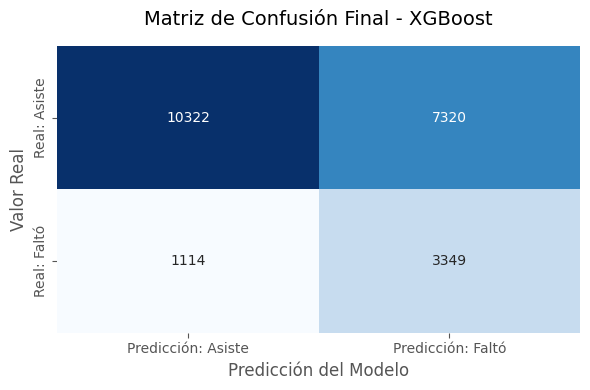

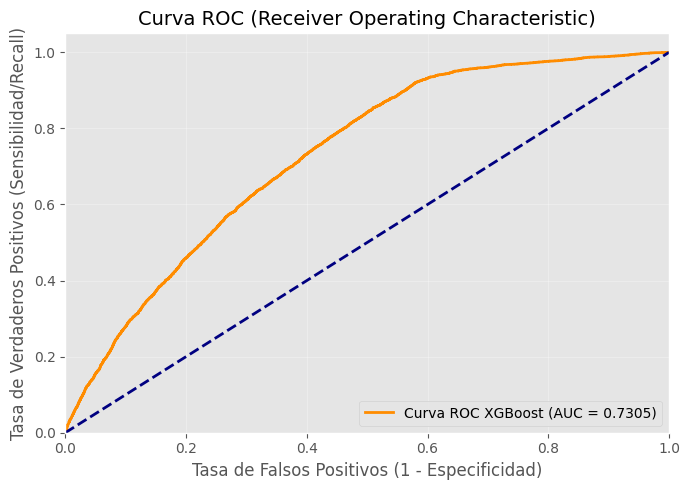

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix

# ==========================================================
# GENERACIÓN DE GRÁFICOS VISUALES PARA EL INFORME (PUNTO 5 Y 6)
# ==========================================================

# 1. GRAFICAR LA MATRIZ DE CONFUSIÓN EN COLORES
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, predicciones)
# Usamos un mapa de colores 'Blues' para darle un tono profesional
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicción: Asiste', 'Predicción: Faltó'],
            yticklabels=['Real: Asiste', 'Real: Faltó'])
plt.title('Matriz de Confusión Final - XGBoost', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.show() # TOMA CAPTURA DE ESTA IMAGEN

print("\n" + "="*50 + "\n")

# 2. GRAFICAR LA CURVA ROC
# Calculamos los ratios de Falsos Positivos (fpr) y Verdaderos Positivos (tpr)
fpr, tpr, thresholds = roc_curve(y_test, probabilidades)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC XGBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Línea de adivinanza al azar
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad/Recall)', fontsize=12)
plt.title('Curva ROC (Receiver Operating Characteristic)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show() # TOMA CAPTURA DE ESTA IMAGEN

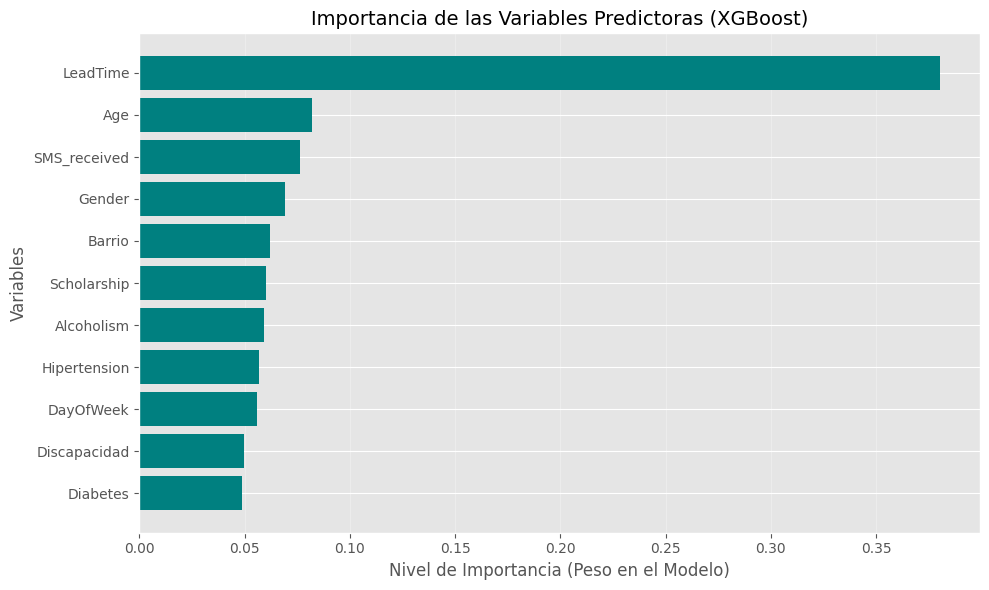

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb
import pandas as pd

# ==========================================================
# GRÁFICO DE IMPORTANCIA DE VARIABLES (FEATURE IMPORTANCE)
# ==========================================================
plt.figure(figsize=(10, 6))

# Extraer las importancias del modelo entrenado
importancias = modelo_seleccionado.feature_importances_
nombres_variables = X_train.columns

# Crear un DataFrame y ordenarlo
df_importancias = pd.DataFrame({'Variable': nombres_variables, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=True)

# Graficar
plt.barh(df_importancias['Variable'], df_importancias['Importancia'], color='teal')
plt.title('Importancia de las Variables Predictoras (XGBoost)', fontsize=14)
plt.xlabel('Nivel de Importancia (Peso en el Modelo)', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show() # TOMA CAPTURA DE ESTO Y PONLO EN EL PUNTO 6